In [1]:
import glob
import h5py
import importlib
import IPython.display as ipd
import numpy as np
import os
import sys
from pathlib import Path
import pickle

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../')
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

## Import saved activations for proof of concept  


Need to run this with independent cues, targets and distractors, where target and distractors are passed through the model without attention 

In [2]:
# model = "word_task_v10_main_feature_gain_config"
model = "word_task_v10_4MGB_ln_first_arch_1"

analysis_dir = Path(f"binaural_unit_activation_analysis/{model}")
# binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_1/word_task_v10_4MGB_ln_first_arch_1_model_activations_0dB_time_avg_diotic.h5
# get shape dict 
with open(analysis_dir / f"{model}_layer_shape_dict_time_avg.pkl", "rb") as f:
    layer_shape_dict = pickle.load(f)

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg_diotic.h5"

h5 = h5py.File(h5_fn, "r") 
# print(h5.keys())
# for key in h5.keys():
#     print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

9 10


[array([0., 0.], dtype=float32),
 88,
 109,
 130,
 152,
 173,
 194,
 215,
 237,
 258,
 279]

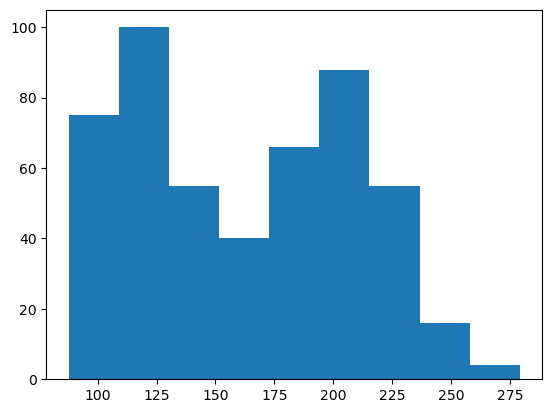

In [11]:
outs = plt.hist(target_f0s, bins=9)
counts, bins = outs[0], outs[1]
print(len(counts), len(bins))
f0_assignments = np.digitize(target_f0s, bins, right=True)
f0_assignments[f0_assignments > 9] = 9
bins = bins.round(0)
f0_bins = bins[f0_assignments]
f0_bins = f0_bins.astype(int)

# group like with locations 
f0_ixs = {}
for f0 in np.unique(f0_bins):
    f0_ixs[f"{f0} Hz"] = np.where(f0_bins == f0)[0]

unique_locs = np.unique(target_locs, axis=0)
unique_f0s = np.unique(f0_bins)

unique_features = list(unique_locs) + list(unique_f0s)
# isinstance(unique_features[-1], int)
unique_features

### proof of concept: get average gains for each location

In [4]:
h5.keys()

<KeysViewHDF5 ['attn0_diff_sex_dist', 'attn0_diff_sex_dist_mixture_diff_corr', 'attn0_mixture_diff', 'attn0_mixture_nat_scene', 'attn0_mixture_same', 'attn0_nat_scene_dist', 'attn0_nat_scene_dist_mixture_nat_scene_corr', 'attn0_same_sex_dist', 'attn0_same_sex_dist_mixture_same_corr', 'attn0_target', 'attn0_target_mixture_diff_corr', 'attn0_target_mixture_nat_scene_corr', 'attn0_target_mixture_same_corr', 'attn1_diff_sex_dist', 'attn1_diff_sex_dist_mixture_diff_corr', 'attn1_gains', 'attn1_mixture_diff', 'attn1_mixture_nat_scene', 'attn1_mixture_same', 'attn1_nat_scene_dist', 'attn1_nat_scene_dist_mixture_nat_scene_corr', 'attn1_same_sex_dist', 'attn1_same_sex_dist_mixture_same_corr', 'attn1_target', 'attn1_target_mixture_diff_corr', 'attn1_target_mixture_nat_scene_corr', 'attn1_target_mixture_same_corr', 'attn2_diff_sex_dist', 'attn2_diff_sex_dist_mixture_diff_corr', 'attn2_gains', 'attn2_mixture_diff', 'attn2_mixture_nat_scene', 'attn2_mixture_same', 'attn2_nat_scene_dist', 'attn2_nat

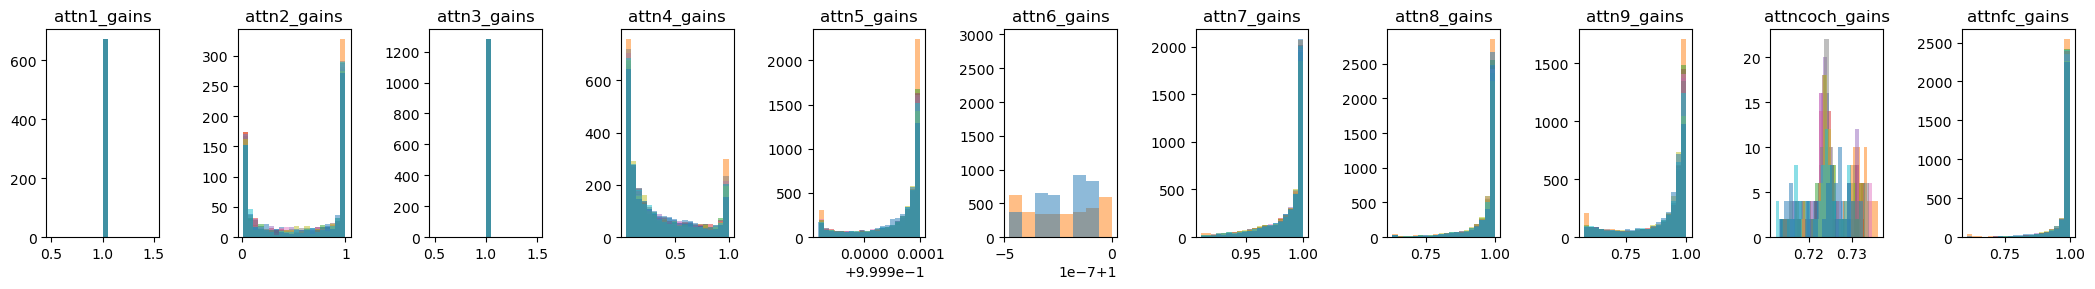

In [12]:
attn_layers = [k for k in h5.keys() if 'gains' in k]

fig, axs = plt.subplots(1, len(attn_layers), figsize=(21, 3))

for ix, layer in enumerate(attn_layers):
    gains = h5[layer][:]
    gain_avg_dict = {}
    for feature in unique_features:
        if isinstance(feature, np.int64):
            gain_ixs = (f0_bins == feature)
        else:
            gain_ixs = (target_locs == feature).all(axis=1)
        if gain_ixs.sum() == 0:
            continue
        avg_gains = gains[gain_ixs].mean(0)
        gain_avg_dict[str(feature)] = {'gains':avg_gains, 'feature':feature}

    for key,vals in gain_avg_dict.items():
        axs[ix].hist(vals['gains'], bins=20, alpha=0.5, )
        axs[ix].set_title(layer)
plt.tight_layout()

## Look at representational sparcification 

Intuition comes from Vinje & Gallant 2000, where instead of comparing sparcity between non-classical and classical receptive fields, we will compare sparsity (a proxy for selectivity) between pre- and post-gain activations.

Sparsity here is measured as $S = \{1 - [\frac{(\sum r_i/n)^2}{\sum (r_i^2/n)}] \} / [1 - (1/n)] $, where $r_i$ was originally the trial-averaged respose at each time point, but here will be the stimuli averaged response of each unit in a given layer.
The delta in sparsity can then be measured as $S_{\text{shift}} = (S_{\text{post-gain}} - S_{\text{pre-gain}}) / (1 - S_{\text{pre-gain}} ) $


In [13]:
h5.keys()

<KeysViewHDF5 ['attn0_diff_sex_dist', 'attn0_diff_sex_dist_mixture_diff_corr', 'attn0_mixture_diff', 'attn0_mixture_nat_scene', 'attn0_mixture_same', 'attn0_nat_scene_dist', 'attn0_nat_scene_dist_mixture_nat_scene_corr', 'attn0_same_sex_dist', 'attn0_same_sex_dist_mixture_same_corr', 'attn0_target', 'attn0_target_mixture_diff_corr', 'attn0_target_mixture_nat_scene_corr', 'attn0_target_mixture_same_corr', 'attn1_diff_sex_dist', 'attn1_diff_sex_dist_mixture_diff_corr', 'attn1_gains', 'attn1_mixture_diff', 'attn1_mixture_nat_scene', 'attn1_mixture_same', 'attn1_nat_scene_dist', 'attn1_nat_scene_dist_mixture_nat_scene_corr', 'attn1_same_sex_dist', 'attn1_same_sex_dist_mixture_same_corr', 'attn1_target', 'attn1_target_mixture_diff_corr', 'attn1_target_mixture_nat_scene_corr', 'attn1_target_mixture_same_corr', 'attn2_diff_sex_dist', 'attn2_diff_sex_dist_mixture_diff_corr', 'attn2_gains', 'attn2_mixture_diff', 'attn2_mixture_nat_scene', 'attn2_mixture_same', 'attn2_nat_scene_dist', 'attn2_nat

In [ ]:
n_layers = len([k for k in h5.keys() if 'relu' in k and 'target' in k and 'conv' in k and 'corr' not in k])
n_layers

10

layer 2 has dead units
layer 4 has dead units
layer 5 has dead units
layer 6 has dead units
layer 7 has dead units
layer 8 has dead units


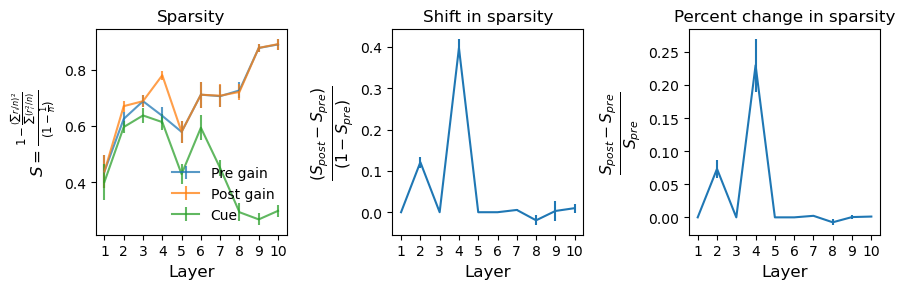

In [40]:
def sparsity_stat(activations):
    n = activations.size
    sqr_mean = activations.mean() ** 2
    mean_sqr = (activations ** 2).mean()
    sparsity = (1 - (sqr_mean / mean_sqr)) / (1 - 1/n)

    # alt implementation
    # mean2 = activations.mean() ** 2
    # var = activations.var() 
    # sparsity2 = (1 - (mean2 / (mean2 + var)) ) / (1 - (1/n))

    return sparsity

def sparsity_shift(s_pre, s_post):
    shift = (s_post - s_pre) / (1 - s_pre)
    return shift 

def percent_change(s_pre, s_post):
    return (s_post - s_pre) / s_pre

def minmax_norm(x, axis=0):
    return (x - x.min(axis=axis, keepdims=True)) / (x.max(axis=axis, keepdims=True) - x.min(axis=axis, keepdims=True))

def unit_norm(x, axis=0):
    return x / np.linalg.norm(x, axis=axis, keepdims=True)



shift_dict = {}
shift_dict['same'] = []
shift_dict['diff'] = []

# init mean and std arrays for each layer
sparsity_cue = np.zeros((n_layers, 2))
sparsity_pre = np.zeros((n_layers, 2))
sparsity_post = np.zeros((n_layers, 2))
sparsity_shifts = np.zeros((n_layers, 2))
sparsity_p_change = np.zeros((n_layers, 2))

n_layers = len([k for k in h5.keys() if 'relu' in k and 'target' in k and 'conv' in k and 'corr' not in k])

for layer_ix in range(n_layers):
    if layer_ix == n_layers-1:
        gain_key = "attnfc"
    else:
        gain_key = f"attn{layer_ix+1}"

    # for i, sex_cond in enumerate(['same', 'diff']):
    mixture_pre_attn = np.concatenate([h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0)
    mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0) 


    n_examples = mixture_pre_attn.shape[0]
    # filter dead units
    target_acts = h5[f"hann_pool_{layer_ix}_target"][:]
    unit_total_act = target_acts.sum(0)

    good_unit_ixs = np.where(unit_total_act > 0)[0]

    if len(good_unit_ixs) != mixture_pre_attn.shape[1]:
        print(f"layer {layer_ix} has dead units")

    trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
    trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]

    cue_reps = h5[f"hann_pool_{layer_ix}_cue_same"][:][:, good_unit_ixs]
    n_cue_egs = cue_reps.shape[0]

    s_cue_list = np.zeros(n_cue_egs)
    s_pre_list = np.zeros(n_examples)
    s_post_list = np.zeros(n_examples)
    s_shift_list = np.zeros(n_examples)
    s_p_change_list = np.zeros(n_examples)

    for ix in range(n_examples):
        if ix < n_cue_egs:
            s_cue = sparsity_stat(cue_reps[ix])
            s_cue_list[ix] = s_cue

        s_pre = sparsity_stat(trial_mean_pre_attn[ix])
        s_post = sparsity_stat(trial_mean_post_attn[ix])
        s_shift = sparsity_shift(s_pre, s_post)
        s_p_change = percent_change(s_pre, s_post)
        s_pre_list[ix] = s_pre
        s_post_list[ix] = s_post
        s_shift_list[ix] = s_shift
        s_p_change_list[ix] = s_p_change
    
    sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
    sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
    sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
    sparsity_shifts[layer_ix] = s_shift_list.mean(), s_shift_list.std()
    sparsity_p_change[layer_ix] = s_p_change_list.mean(), s_p_change_list.std()

    # s_pre = sparsity_stat(trial_mean_pre_attn)
    # s_post = sparsity_stat(trial_mean_post_attn)
    # s_shift = sparsity_shift(s_pre, s_post)
    # shifts.append(s_shift)

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
x = np.arange(n_layers)

fontsize = 12


axs[0].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75)
axs[0].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=0.75)
axs[0].errorbar(x, sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75)
axs[0].set_title('Sparsity', fontsize=fontsize)
axs[0].set_xlabel('Layer', fontsize=fontsize)
axs[0].set_ylabel(r'$S = \frac{1 - \frac{(\sum r_i / n )^2}{\sum (r_i^2 / n )}}{(1 - \frac{1}{n})}$', fontsize=fontsize)
axs[0].legend(loc='lower right', frameon=False)

axs[1].errorbar(x, sparsity_shifts[:, 0], yerr=sparsity_shifts[:, 1])
axs[1].set_title("Shift in sparsity", fontsize=fontsize)
axs[1].set_xlabel('Layer', fontsize=fontsize)
axs[1].set_ylabel(r'$\frac{(S_{post} - S_{pre})}{(1 - S_{pre})}$', fontsize=fontsize+4)


axs[2].errorbar(x, sparsity_p_change[:, 0], yerr=sparsity_p_change[:, 1])
axs[2].set_title("Percent change in sparsity", fontsize=fontsize)
axs[2].set_xlabel('Layer', fontsize=fontsize)
axs[2].set_ylabel(r'$\frac{S_{post} - S_{pre}}{S_{pre}}$', fontsize=fontsize+4)

## set xtcik labels to all layer numbers 
for ax in axs:
    ax.set_xticks(x)
    ax.set_xticklabels(x+1)
plt.tight_layout()


# axs.bar(shift_dict['diff'], label='diff')


layer 2 has dead units
layer 4 has dead units
layer 5 has dead units
layer 6 has dead units


layer 7 has dead units
layer 8 has dead units
layer 2 has dead units
layer 4 has dead units
layer 5 has dead units
layer 6 has dead units
layer 7 has dead units
layer 8 has dead units
layer 2 has dead units
layer 4 has dead units
layer 5 has dead units
layer 6 has dead units
layer 7 has dead units
layer 8 has dead units


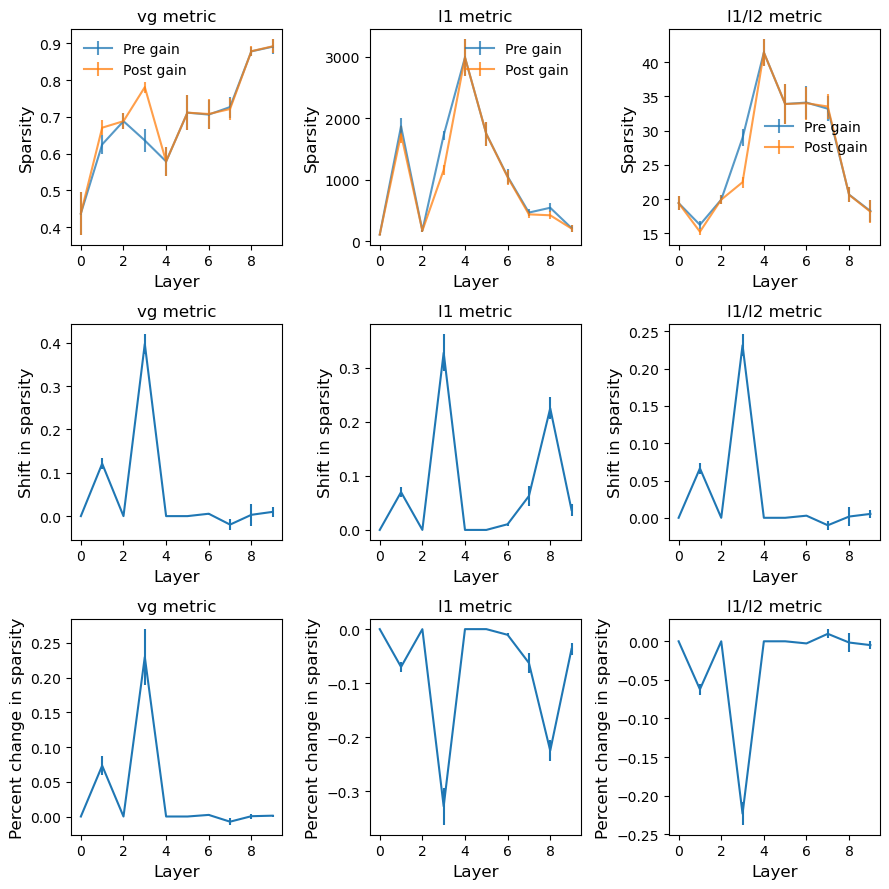

In [45]:
def sparsity_stat(activations):
    n = activations.size
    sqr_mean = activations.mean() ** 2
    mean_sqr = (activations ** 2).mean()
    sparsity = (1 - (sqr_mean / mean_sqr)) / (1 - 1/n)

    # alt implementation
    # mean2 = activations.mean() ** 2
    # var = activations.var() 
    # sparsity2 = (1 - (mean2 / (mean2 + var)) ) / (1 - (1/n))

    return sparsity

def sparsity_shift(s_pre, s_post):
    shift = (s_post - s_pre) / (1 - s_pre)
    return shift 

def percent_change(s_pre, s_post):
    return (s_post - s_pre) / s_pre

def minmax_norm(x, axis=0):
    return (x - x.min(axis=axis, keepdims=True)) / (x.max(axis=axis, keepdims=True) - x.min(axis=axis, keepdims=True))

def unit_norm(x, axis=0):
    return x / np.linalg.norm(x, axis=axis, keepdims=True)



shift_dict = {}
shift_dict['same'] = []
shift_dict['diff'] = []

fig, axs = plt.subplots(3, 3, figsize=(9, 9))

fontsize = 12



# init mean and std arrays for each layer


n_layers = len([k for k in h5.keys() if 'relu' in k and 'target' in k and 'conv' in k and 'corr' not in k])
x = np.arange(n_layers)

for cond_ix, metric in enumerate(['vg', 'l1', 'l1/l2']):

    sparsity_pre = np.zeros((n_layers, 2))
    sparsity_post = np.zeros((n_layers, 2))
    sparsity_shifts = np.zeros((n_layers, 2))
    sparsity_p_change = np.zeros((n_layers, 2))


    for layer_ix in range(n_layers):
        if layer_ix == n_layers-1:
            gain_key = "attnfc"
        else:
            gain_key = f"attn{layer_ix+1}"

            # filter dead units
        target_acts = h5[f"hann_pool_{layer_ix}_target"][:]
        unit_total_act = target_acts.sum(0)

        good_unit_ixs = np.where(unit_total_act > 0)[0]

        # for i, sex_cond in enumerate(['same', 'diff']):
        mixture_pre_attn = np.concatenate([h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0)
        mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0) 

 
        if len(good_unit_ixs) != mixture_pre_attn.shape[1]:
            print(f"layer {layer_ix} has dead units")

        trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
        trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]
        n_examples = trial_mean_pre_attn.shape[0]

        s_pre_list = np.zeros(n_examples)
        s_post_list = np.zeros(n_examples)
        s_shift_list = np.zeros(n_examples)
        s_p_change_list = np.zeros(n_examples)

        for ix in range(n_examples):
            if metric == 'vg':
                s_pre = sparsity_stat(trial_mean_pre_attn[ix])
                s_post = sparsity_stat(trial_mean_post_attn[ix])
            elif metric == 'l1':
                s_pre = np.linalg.norm(trial_mean_pre_attn[ix], ord=1)
                s_post = np.linalg.norm(trial_mean_post_attn[ix], ord=1)
            elif metric == 'l1/l2':
                s_pre = np.linalg.norm(trial_mean_pre_attn[ix], ord=1) / np.linalg.norm(trial_mean_pre_attn[ix], ord=2)
                s_post = np.linalg.norm(trial_mean_post_attn[ix], ord=1) / np.linalg.norm(trial_mean_post_attn[ix], ord=2)
            s_shift = sparsity_shift(s_pre, s_post)
            s_p_change = percent_change(s_pre, s_post)
            s_pre_list[ix] = s_pre
            s_post_list[ix] = s_post
            s_shift_list[ix] = s_shift
            s_p_change_list[ix] = s_p_change
        
        sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
        sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
        sparsity_shifts[layer_ix] = s_shift_list.mean(), s_shift_list.std()
        sparsity_p_change[layer_ix] = s_p_change_list.mean(), s_p_change_list.std()

        # s_pre = sparsity_stat(trial_mean_pre_attn)
        # s_post = sparsity_stat(trial_mean_post_attn)
        # s_shift = sparsity_shift(s_pre, s_post)
        # shifts.append(s_shift)



    axs[0, cond_ix].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75)
    axs[0, cond_ix].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=0.75)
    axs[0, cond_ix].set_ylabel('Sparsity', fontsize=fontsize)
    axs[0, cond_ix].set_xlabel('Layer', fontsize=fontsize)
    axs[0, cond_ix].set_title(f'{metric} metric', fontsize=fontsize)
    # axs[0, cond_ix].set_ylim(0.2,0.9)

    # axs[0, cond_ix].set_ylabel(r'$S = \frac{1 - \frac{(\sum r_i / n )^2}{\sum (r_i^2 / n )}}{(1 - \frac{1}{n})}$', fontsize=fontsize)
    axs[0, cond_ix].legend(loc='best', frameon=False)

    axs[1, cond_ix].errorbar(x, sparsity_shifts[:, 0], yerr=sparsity_shifts[:, 1])
    axs[1, cond_ix].set_ylabel("Shift in sparsity", fontsize=fontsize)
    axs[1, cond_ix].set_xlabel('Layer', fontsize=fontsize)
    axs[1, cond_ix].set_title(f'{metric} metric', fontsize=fontsize)
    # axs[1, cond_ix].set_ylim(-.01,0.41)

    # axs[1, cond_ix].set_ylabel(r'$\frac{(S_{post} - S_{pre})}{(1 - S_{pre})}$', fontsize=fontsize+4)


    axs[2, cond_ix].errorbar(x, sparsity_p_change[:, 0], yerr=sparsity_p_change[:, 1])
    axs[2, cond_ix].set_ylabel("Percent change in sparsity", fontsize=fontsize)
    axs[2, cond_ix].set_xlabel('Layer', fontsize=fontsize)
    axs[2, cond_ix].set_title(f'{metric} metric', fontsize=fontsize)
    # axs[2, cond_ix].set_ylim(0,0.31)


plt.tight_layout()


# axs.bar(shift_dict['diff'], label='diff')


layer 2 has dead units
layer 4 has dead units
layer 5 has dead units
layer 6 has dead units
layer 7 has dead units
layer 8 has dead units
layer 2 has dead units
layer 4 has dead units
layer 5 has dead units
layer 6 has dead units
layer 7 has dead units
layer 8 has dead units
layer 2 has dead units
layer 4 has dead units
layer 5 has dead units
layer 6 has dead units
layer 7 has dead units
layer 8 has dead units


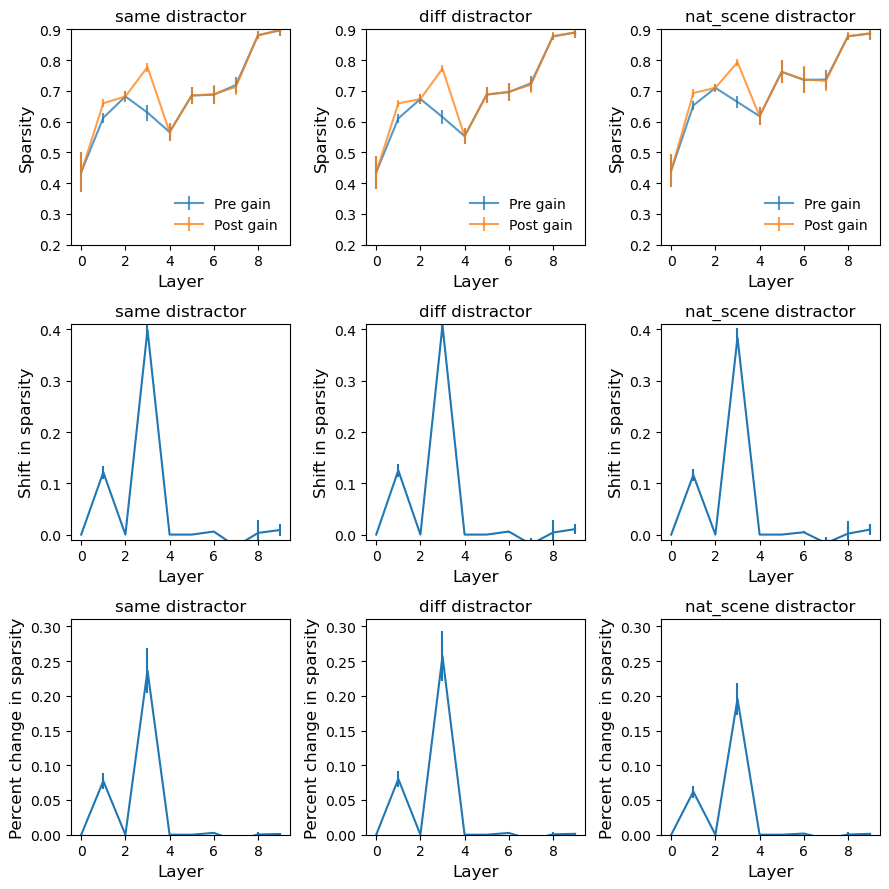

In [47]:
def sparsity_stat(activations):
    n = activations.size
    sqr_mean = activations.mean() ** 2
    mean_sqr = (activations ** 2).mean()
    sparsity = (1 - (sqr_mean / mean_sqr)) / (1 - 1/n)

    # alt implementation
    # mean2 = activations.mean() ** 2
    # var = activations.var() 
    # sparsity2 = (1 - (mean2 / (mean2 + var)) ) / (1 - (1/n))

    return sparsity

def sparsity_shift(s_pre, s_post):
    shift = (s_post - s_pre) / (1 - s_pre)
    return shift 

def percent_change(s_pre, s_post):
    return (s_post - s_pre) / s_pre

def minmax_norm(x, axis=0):
    return (x - x.min(axis=axis, keepdims=True)) / (x.max(axis=axis, keepdims=True) - x.min(axis=axis, keepdims=True))

def unit_norm(x, axis=0):
    return x / np.linalg.norm(x, axis=axis, keepdims=True)



shift_dict = {}
shift_dict['same'] = []
shift_dict['diff'] = []

fig, axs = plt.subplots(3, 3, figsize=(9, 9))
x = np.arange(7)

fontsize = 12


# init mean and std arrays for each layer
n_layers = len([k for k in h5.keys() if 'relu' in k and 'target' in k and 'conv' in k and 'corr' not in k])
x = np.arange(n_layers)
for cond_ix, dist_cond in enumerate(['same', 'diff', 'nat_scene']):

    sparsity_pre = np.zeros((n_layers, 2))
    sparsity_post = np.zeros((n_layers, 2))
    sparsity_shifts = np.zeros((n_layers, 2))
    sparsity_p_change = np.zeros((n_layers, 2))

    for layer_ix in range(n_layers):
        if layer_ix == n_layers-1:
            gain_key = "attnfc"
        else:
            gain_key = f"attn{layer_ix+1}"

            # filter dead units
        target_acts = h5[f"hann_pool_{layer_ix}_target"][:]
        unit_total_act = target_acts.sum(0)

        good_unit_ixs = np.where(unit_total_act > 0)[0]


        # for i, sex_cond in enumerate(['same', 'diff']):
        # mixture_pre_attn = np.concatenate([h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0)
        # mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0) 

        mixture_pre_attn = h5[f"hann_pool_{layer_ix}_mixture_{dist_cond}"][:]
        mixture_post_attn = h5[f"{gain_key}_mixture_{dist_cond}"][:]




        if len(good_unit_ixs) != mixture_pre_attn.shape[1]:
            print(f"layer {layer_ix} has dead units")

        trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
        trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]
        n_examples = trial_mean_pre_attn.shape[0]

        s_pre_list = np.zeros(n_examples)
        s_post_list = np.zeros(n_examples)
        s_shift_list = np.zeros(n_examples)
        s_p_change_list = np.zeros(n_examples)

        for ix in range(n_examples):
            s_pre = sparsity_stat(trial_mean_pre_attn[ix])
            s_post = sparsity_stat(trial_mean_post_attn[ix])
            s_shift = sparsity_shift(s_pre, s_post)
            s_p_change = percent_change(s_pre, s_post)
            s_pre_list[ix] = s_pre
            s_post_list[ix] = s_post
            s_shift_list[ix] = s_shift
            s_p_change_list[ix] = s_p_change
        
        sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
        sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
        sparsity_shifts[layer_ix] = s_shift_list.mean(), s_shift_list.std()
        sparsity_p_change[layer_ix] = s_p_change_list.mean(), s_p_change_list.std()

        # s_pre = sparsity_stat(trial_mean_pre_attn)
        # s_post = sparsity_stat(trial_mean_post_attn)
        # s_shift = sparsity_shift(s_pre, s_post)
        # shifts.append(s_shift)



    axs[0, cond_ix].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75)
    axs[0, cond_ix].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=0.75)
    axs[0, cond_ix].set_ylabel('Sparsity', fontsize=fontsize)
    axs[0, cond_ix].set_xlabel('Layer', fontsize=fontsize)
    axs[0, cond_ix].set_title(f'{dist_cond} distractor', fontsize=fontsize)
    axs[0, cond_ix].set_ylim(0.2,0.9)

    # axs[0, cond_ix].set_ylabel(r'$S = \frac{1 - \frac{(\sum r_i / n )^2}{\sum (r_i^2 / n )}}{(1 - \frac{1}{n})}$', fontsize=fontsize)
    axs[0, cond_ix].legend(loc='lower right', frameon=False)

    axs[1, cond_ix].errorbar(x, sparsity_shifts[:, 0], yerr=sparsity_shifts[:, 1])
    axs[1, cond_ix].set_ylabel("Shift in sparsity", fontsize=fontsize)
    axs[1, cond_ix].set_xlabel('Layer', fontsize=fontsize)
    axs[1, cond_ix].set_title(f'{dist_cond} distractor', fontsize=fontsize)
    axs[1, cond_ix].set_ylim(-.01,0.41)

    # axs[1, cond_ix].set_ylabel(r'$\frac{(S_{post} - S_{pre})}{(1 - S_{pre})}$', fontsize=fontsize+4)


    axs[2, cond_ix].errorbar(x, sparsity_p_change[:, 0], yerr=sparsity_p_change[:, 1])
    axs[2, cond_ix].set_ylabel("Percent change in sparsity", fontsize=fontsize)
    axs[2, cond_ix].set_xlabel('Layer', fontsize=fontsize)
    axs[2, cond_ix].set_title(f'{dist_cond} distractor', fontsize=fontsize)
    axs[2, cond_ix].set_ylim(0,0.31)

        # axs[2, cond_ix].set_ylabel(r'$\frac{S_{post} - S_{pre}}{S_{pre}}$', fontsize=fontsize+4)

## set xtcik labels to all layer numbers 
# for ax in axs.flatten():
#     ax.set_xticks(x)
#     ax.set_xticklabels(x+1)
plt.tight_layout()


# axs.bar(shift_dict['diff'], label='diff')


In [14]:
print(h5.keys())

<KeysViewHDF5 ['attn0_diff_sex_dist', 'attn0_diff_sex_dist_mixture_diff_corr', 'attn0_mixture_diff', 'attn0_mixture_nat_scene', 'attn0_mixture_same', 'attn0_nat_scene_dist', 'attn0_nat_scene_dist_mixture_nat_scene_corr', 'attn0_same_sex_dist', 'attn0_same_sex_dist_mixture_same_corr', 'attn0_target', 'attn0_target_mixture_diff_corr', 'attn0_target_mixture_nat_scene_corr', 'attn0_target_mixture_same_corr', 'attn1_diff_sex_dist', 'attn1_diff_sex_dist_mixture_diff_corr', 'attn1_gains', 'attn1_mixture_diff', 'attn1_mixture_nat_scene', 'attn1_mixture_same', 'attn1_nat_scene_dist', 'attn1_nat_scene_dist_mixture_nat_scene_corr', 'attn1_same_sex_dist', 'attn1_same_sex_dist_mixture_same_corr', 'attn1_target', 'attn1_target_mixture_diff_corr', 'attn1_target_mixture_nat_scene_corr', 'attn1_target_mixture_same_corr', 'attn2_diff_sex_dist', 'attn2_diff_sex_dist_mixture_diff_corr', 'attn2_gains', 'attn2_mixture_diff', 'attn2_mixture_nat_scene', 'attn2_mixture_same', 'attn2_nat_scene_dist', 'attn2_nat

In [11]:
h5[f"hann_pool_{layer_ix}_cue"][:]

KeyError: "Unable to synchronously open object (object 'hann_pool_6_cue' doesn't exist)"

layer 2 has dead units
layer 3 has dead units
layer 4 has dead units
layer 5 has dead units


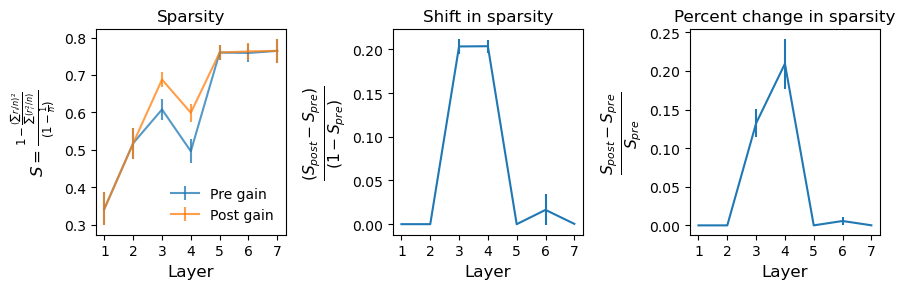

In [10]:
def sparsity_stat(activations):
    n = activations.size
    sqr_mean = activations.mean() ** 2
    mean_sqr = (activations ** 2).mean()
    sparsity = (1 - (sqr_mean / mean_sqr)) / (1 - 1/n)

    # alt implementation
    # mean2 = activations.mean() ** 2
    # var = activations.var() 
    # sparsity2 = (1 - (mean2 / (mean2 + var)) ) / (1 - (1/n))

    return sparsity

def sparsity_shift(s_pre, s_post):
    shift = (s_post - s_pre) / (1 - s_pre)
    return shift 

def percent_change(s_pre, s_post):
    return (s_post - s_pre) / s_pre

def minmax_norm(x, axis=0):
    return (x - x.min(axis=axis, keepdims=True)) / (x.max(axis=axis, keepdims=True) - x.min(axis=axis, keepdims=True))

def unit_norm(x, axis=0):
    return x / np.linalg.norm(x, axis=axis, keepdims=True)



shift_dict = {}
shift_dict['same'] = []
shift_dict['diff'] = []

# init mean and std arrays for each layer
sparsity_pre = np.zeros((7, 2))
sparsity_post = np.zeros((7, 2))
sparsity_shifts = np.zeros((7, 2))
sparsity_p_change = np.zeros((7, 2))

for layer_ix in range(7):
    if layer_ix == 6:
        gain_key = "attnfc"
    else:
        gain_key = f"attn{layer_ix+1}"

    # for i, sex_cond in enumerate(['same', 'diff']):
    # mixture_pre_attn = np.concatenate([h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0)
    # mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0) 
    mixture_pre_attn = h5[f"hann_pool_{layer_ix}_target"][:]
    mixture_post_attn = h5[f"{gain_key}_target"][:]
    n_examples = mixture_pre_attn.shape[0]
    # filter dead units
    target_acts = h5[f"hann_pool_{layer_ix}_target"][:]
    unit_total_act = target_acts.sum(0)

    good_unit_ixs = np.where(unit_total_act > 0)[0]

    if len(good_unit_ixs) != mixture_pre_attn.shape[1]:
        print(f"layer {layer_ix} has dead units")

    trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
    trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]
    s_pre_list = np.zeros(n_examples)
    s_post_list = np.zeros(n_examples)
    s_shift_list = np.zeros(n_examples)
    s_p_change_list = np.zeros(n_examples)

    for ix in range(n_examples):
        s_pre = sparsity_stat(trial_mean_pre_attn[ix])
        s_post = sparsity_stat(trial_mean_post_attn[ix])
        s_shift = sparsity_shift(s_pre, s_post)
        s_p_change = percent_change(s_pre, s_post)
        s_pre_list[ix] = s_pre
        s_post_list[ix] = s_post
        s_shift_list[ix] = s_shift
        s_p_change_list[ix] = s_p_change
    
    sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
    sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
    sparsity_shifts[layer_ix] = s_shift_list.mean(), s_shift_list.std()
    sparsity_p_change[layer_ix] = s_p_change_list.mean(), s_p_change_list.std()

    # s_pre = sparsity_stat(trial_mean_pre_attn)
    # s_post = sparsity_stat(trial_mean_post_attn)
    # s_shift = sparsity_shift(s_pre, s_post)
    # shifts.append(s_shift)

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
x = np.arange(7)

fontsize = 12


axs[0].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75)
axs[0].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=0.75)
axs[0].set_title('Sparsity', fontsize=fontsize)
axs[0].set_xlabel('Layer', fontsize=fontsize)
axs[0].set_ylabel(r'$S = \frac{1 - \frac{( \sum r_i / n ) ^2}{\sum (r_i^2 / n )}}{(1 - \frac{1}{n})}$', fontsize=fontsize)
axs[0].legend(loc='lower right', frameon=False)

axs[1].errorbar(x, sparsity_shifts[:, 0], yerr=sparsity_shifts[:, 1])
axs[1].set_title("Shift in sparsity", fontsize=fontsize)
axs[1].set_xlabel('Layer', fontsize=fontsize)
axs[1].set_ylabel(r'$\frac{(S_{post} - S_{pre})}{(1 - S_{pre})}$', fontsize=fontsize+4)


axs[2].errorbar(x, sparsity_p_change[:, 0], yerr=sparsity_p_change[:, 1])
axs[2].set_title("Percent change in sparsity", fontsize=fontsize)
axs[2].set_xlabel('Layer', fontsize=fontsize)
axs[2].set_ylabel(r'$\frac{S_{post} - S_{pre}}{S_{pre}}$', fontsize=fontsize+4)

## set xtcik labels to all layer numbers 
for ax in axs:
    ax.set_xticks(x)
    ax.set_xticklabels(x+1)
plt.tight_layout()


# axs.bar(shift_dict['diff'], label='diff')


<ErrorbarContainer object of 3 artists>

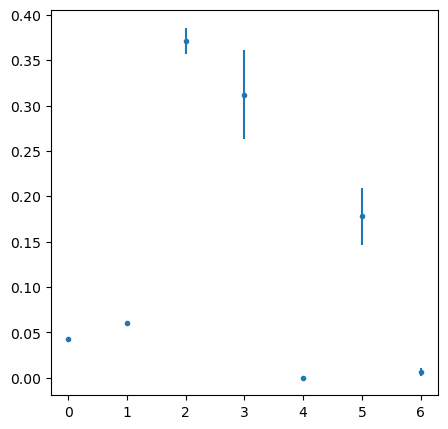

In [39]:
def sparsity_stat(activations):
    n = activations.size
    sqr_mean = activations.mean() ** 2
    mean_sqr = (activations ** 2).mean()
    sparsity = (1 - (sqr_mean / mean_sqr)) / (1 - 1/n)
    return sparsity

def sparsity_shift(s_pre, s_post):
    shift = (s_post - s_pre) / (1 - s_pre)
    return shift 

def minmax_norm(x, axis=0):
    return (x - x.min(axis=axis, keepdims=True)) / (x.max(axis=axis, keepdims=True) - x.min(axis=axis, keepdims=True))

def unit_norm(x, axis=0):
    return x / np.linalg.norm(x, axis=axis, keepdims=True)



shift_dict = {}
shift_dict['same'] = []
shift_dict['diff'] = []
per_layer_stats = np.zeros((7, 2))
for layer_ix in range(7):
    if layer_ix == 6:
        gain_key = "attnfc"
    else:
        gain_key = f"attn{layer_ix+1}"

    # for i, sex_cond in enumerate(['same', 'diff']):
    mixture_pre_attn = np.concatenate([h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0)
    mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in ['same', 'diff', 'nat_scene']], axis=0) 
    n_examples = mixture_pre_attn.shape[0]


    # filter dead units
    target_acts = h5[f"hann_pool_{layer_ix}_target"][:]
    unit_total_act = target_acts.sum(0)

    good_unit_ixs = np.where(unit_total_act > 0)[0]

    example_ratios = []
    for i in range(n_examples):
        pre_gain_norm = np.linalg.norm(mixture_pre_attn[i, good_unit_ixs], ord=1)
        post_gain_norm = np.linalg.norm(mixture_post_attn[i, good_unit_ixs], ord=1)
        example_ratios.append(1 - (post_gain_norm / pre_gain_norm))

    mean = np.mean(example_ratios)
    std = np.std(example_ratios)

    per_layer_stats[layer_ix,:] = [mean, std]

fig, axs = plt.subplots(1, figsize=(5, 5))
axs.errorbar(np.arange(7), per_layer_stats[:,0], yerr=per_layer_stats[:,1], fmt='.')
# axs.set_title("Mean Gain Ratio per Layer")

  


0.9968193

## Make pie charts per layer for % unit tuning and % units accounting for target 

/tmp/ipykernel_3950489/553614606.py:4: RuntimeWarning: divide by zero encountered in log
  ratios = np.log(target / distractor)
/tmp/ipykernel_3950489/553614606.py:4: RuntimeWarning: divide by zero encountered in divide
  ratios = np.log(target / distractor)
/tmp/ipykernel_3950489/553614606.py:4: RuntimeWarning: invalid value encountered in divide
  ratios = np.log(target / distractor)


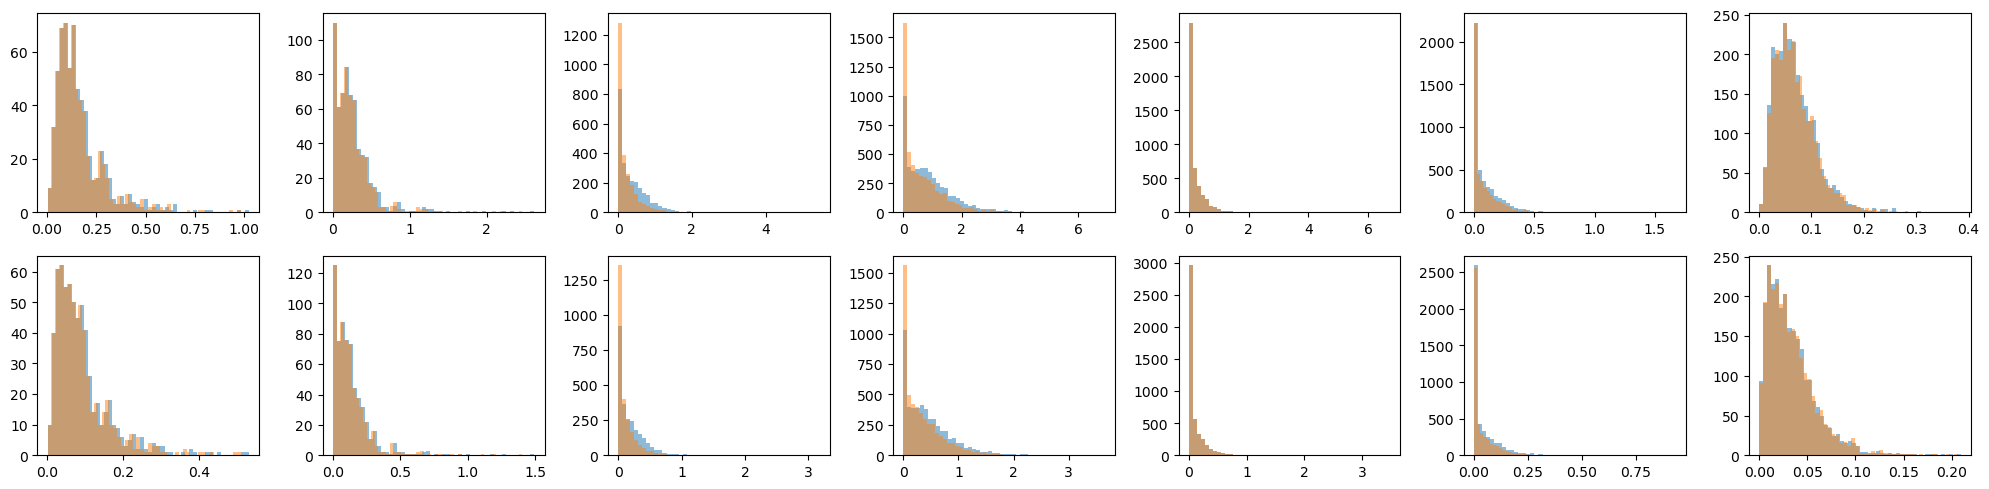

In [78]:
### Use same sex case as eg 

layer_ix = 2 # is 4th layer with 0 ix 
sex_cond = 'same'

n_examples = 100

fig, axs = plt.subplots(2,7, figsize=(20,5))

labels=['Target', 'Distractor']


for layer_ix in range(7):

    n_units = h5[f"hann_pool_{layer_ix}_target"].shape[1]
    # gain ix is layer_ix + 1
    if layer_ix == 6:
        gain_key = "attnfc"
    else:
        gain_key = f"attn{layer_ix+1}"

    # pre_gain_prop = np.zeros((n_examples))
    # post_gain_prop = np.zeros((n_examples))

    pre_gain_acts = np.zeros((n_examples, n_units))
    post_gain_acts = np.zeros((n_examples, n_units))


    pre_gain_acts_tgt = np.zeros((n_examples, n_units))
    post_gain_acts_tgt = np.zeros((n_examples, n_units))
    
    rank_diffs = np.zeros((n_examples))
    target_acts_pre = []
    target_acts_post = []
    for stim_ix in range(n_examples):
        target_alone = h5[f"hann_pool_{layer_ix}_target"][stim_ix]
        distractor_alone = h5[f"hann_pool_{layer_ix}_{sex_cond}_sex_dist"][stim_ix]

        unit_affinity_rank, unit_affinity_ratio = get_unit_affinity_rank(target_alone, distractor_alone)

        target_unit_ixs = np.argwhere(unit_affinity_ratio > 0).flatten()


        mixture_pre_attn = h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][stim_ix]
        mixture_post_attn = h5[f"{gain_key}_mixture_{sex_cond}"][stim_ix]


        pre_gain_acts[stim_ix] = mixture_pre_attn
        post_gain_acts[stim_ix] = mixture_post_attn
        
        pre_gain_acts_tgt[stim_ix, target_unit_ixs] = mixture_pre_attn[target_unit_ixs]
        post_gain_acts_tgt[stim_ix, target_unit_ixs] = mixture_post_attn[target_unit_ixs]


        # pre_gain_prop[stim_ix] = mixture_pre_attn[target_unit_ixs].sum() / mixture_pre_attn.sum()
        # post_gain_prop[stim_ix] = mixture_post_attn[target_unit_ixs].sum() / mixture_post_attn.sum()
    
    # pre_gain_dist_prop = 1 - pre_gain_prop
    # post_gain_dist_prop = 1 - post_gain_prop

    # pre_gain_to_plot = [pre_gain_prop.mean(), pre_gain_dist_prop.mean()]
    # post_gain_to_plot = [post_gain_prop.mean(), post_gain_dist_prop.mean()]
    # axs[0, layer_ix].pie(pre_gain_to_plot, labels=labels, autopct='%1.1f%%')

    axs[0, layer_ix].hist(pre_gain_acts.mean(0), bins=50, alpha=0.5, label='Pre-Attention')
    axs[0, layer_ix].hist(post_gain_acts.mean(0), bins=50, alpha=0.5, label='Post-Attention')

    # target_acts_pre = np.concatenate(target_acts_pre)
    # target_acts_post = np.concatenate(target_acts_post)
    axs[1, layer_ix].hist(pre_gain_acts_tgt.mean(0), bins=50, alpha=0.5, label='Pre-Attention')
    axs[1, layer_ix].hist(post_gain_acts_tgt.mean(0), bins=50, alpha=0.5, label='Post-Attention')

    # axs[0, layer_ix].hist(pre_gain_acts.mean(0), bins=25, alpha=0.5, label='Pre-Attention')
    # axs[0, layer_ix].hist(post_gain_acts.mean(0), bins=25, alpha=0.5, label='Post-Attention')

    # axs[1, layer_ix].pie(post_gain_to_plot, labels=labels,  autopct='%1.1f%%')

    


    # for ax in axs[:, layer_ix]:
    #     ax.set_xticks([0, n_units])
    #     ax.set_xticklabels(['Most\nattended', 'Least\nattended'])
    #     # ax.set_ylabel("Relative reduction\nin activation");
    # if layer_ix == 3:
    #     axs[1, layer_ix].set_xlabel("Units sorted by attentional priority")

    # axs[0, layer_ix].set_title(f"Layer {layer_ix}\nGains")
    # axs[1, layer_ix].set_title(f"Representational\nsharpening")
    # axs[1, layer_ix].set_ylabel("% max. activation")
    # axs[0, layer_ix].set_ylabel("Gain")
# plt.subplot(122)

plt.tight_layout()

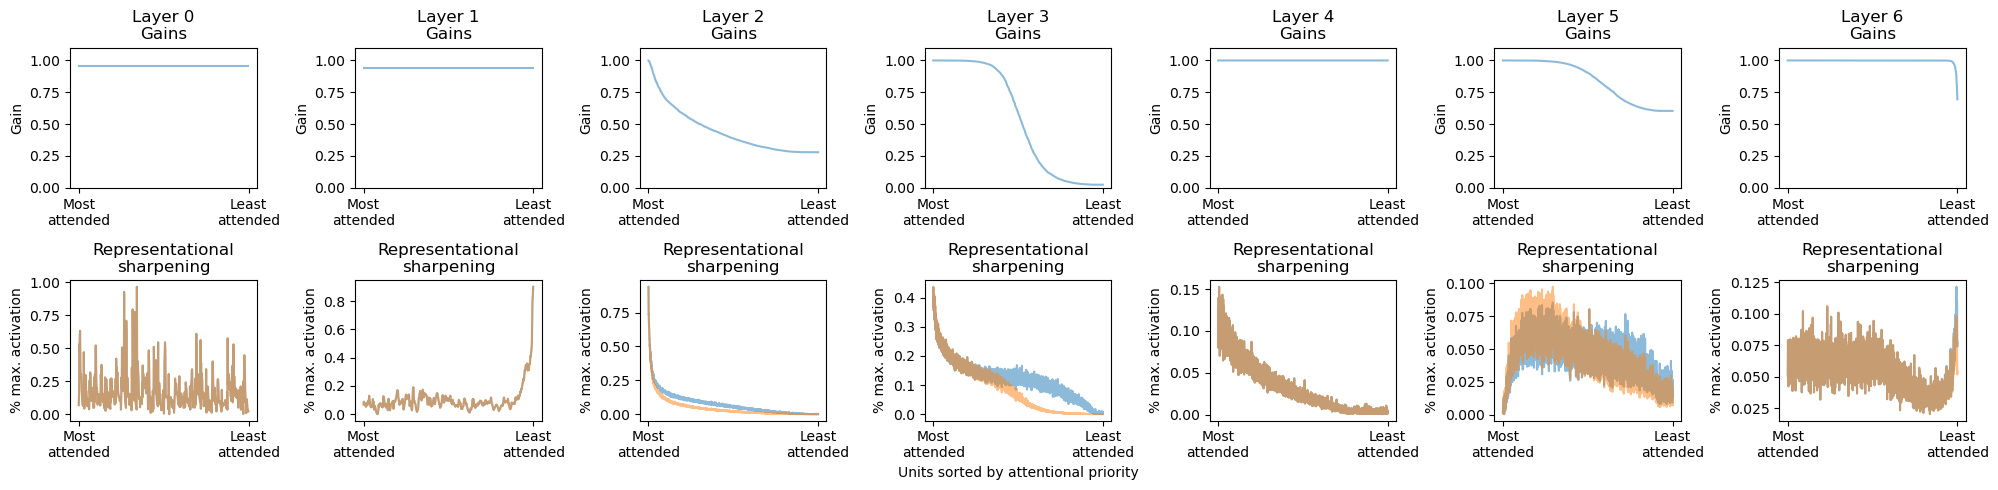

In [86]:
### Use same sex case as eg 

layer_ix = 2 # is 4th layer with 0 ix 
sex_cond = 'diff'

n_examples = 100

fig, axs = plt.subplots(2,7, figsize=(20,5))


skew_diff = np.zeros((7))

for layer_ix in range(7):

    n_units = h5[f"hann_pool_{layer_ix}_target"].shape[1]
    # gain ix is layer_ix + 1
    if layer_ix == 6:
        gain_key = "attnfc"
    else:
        gain_key = f"attn{layer_ix+1}"

    pre_gain_acts = np.zeros((n_examples, n_units))
    post_gain_acts = np.zeros((n_examples, n_units))

    rank_diffs = np.zeros((n_examples))
    for stim_ix in range(n_examples):
        target_alone = h5[f"hann_pool_{layer_ix}_target"][stim_ix]
        # distractor_alone = h5[f"hann_pool_{layer_ix}_{sex_cond}_sex_dist"][stim_ix]

        # get unit rank from gains 
        gains = h5[f'{gain_key}_gains'][stim_ix]
        unit_rank = np.argsort(gains)[::-1]
        # unit_rank = np.argsort(target_alone)[::-1]

        # rank_diffs[stim_ix] = np.sum(target_unit_rank - unit_rank)

        mixture_pre_attn = h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][stim_ix]
        mixture_post_attn = h5[f"{gain_key}_mixture_{sex_cond}"][stim_ix]

        pre_gain_acts[stim_ix] = minmax_norm(mixture_pre_attn[unit_rank])
        post_gain_acts[stim_ix] = minmax_norm(mixture_post_attn[unit_rank])

    # pre_skew = scipy.stats.skewtest(pre_gain_acts.mean(0)).statistic
    # post_skew = scipy.stats.skewtest(post_gain_acts.mean(0)).statistic

    # skew_diff[layer_ix] = post_skew - pre_skew
    # 
    axs[0,layer_ix].plot(gains[unit_rank],  alpha=0.5);
    axs[0, layer_ix].set_ylim(0,1.1)

    axs[1,layer_ix].plot(pre_gain_acts.mean(0), label='Pre attn', alpha=0.5);
    axs[1, layer_ix].plot(post_gain_acts.mean(0), label='Post attn', alpha=0.5);

    for ax in axs[:, layer_ix]:
        ax.set_xticks([0, n_units])
        ax.set_xticklabels(['Most\nattended', 'Least\nattended'])
        # ax.set_ylabel("Relative reduction\nin activation");
    if layer_ix == 3:
        axs[1, layer_ix].set_xlabel("Units sorted by attentional priority")

    axs[0, layer_ix].set_title(f"Layer {layer_ix}\nGains")
    axs[1, layer_ix].set_title(f"Representational\nsharpening")
    axs[1, layer_ix].set_ylabel("% max. activation")
    axs[0, layer_ix].set_ylabel("Gain")
# plt.subplot(122)

plt.tight_layout()

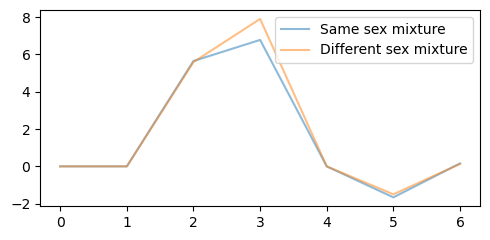

In [177]:
import scipy 

### Use same sex case as eg 

layer_ix = 2 # is 4th layer with 0 ix 

n_examples = 100

fig, axs = plt.subplots(1, figsize=(5, 2.5))


skew_diff = np.zeros((7, 2))

for layer_ix in range(7):

    for sx, sex_cond in enumerate(['same', 'diff']):
        n_units = h5[f"hann_pool_{layer_ix}_target"].shape[1]
        # gain ix is layer_ix + 1
        if layer_ix == 6:
            gain_key = "attnfc"
        else:
            gain_key = f"attn{layer_ix+1}"

        pre_gain_acts = np.zeros((n_examples, n_units))
        post_gain_acts = np.zeros((n_examples, n_units))

        rank_diffs = np.zeros((n_examples))
        for stim_ix in range(n_examples):
            target_alone = h5[f"hann_pool_{layer_ix}_target"][stim_ix]
            # distractor_alone = h5[f"hann_pool_{layer_ix}_{sex_cond}_sex_dist"][stim_ix]

            # get unit rank from gains 
            gains = h5[f'{gain_key}_gains'][stim_ix]
            # unit_rank = np.argsort(gains)[::-1]
            unit_rank = np.argsort(target_alone)[::-1]

            # rank_diffs[stim_ix] = np.sum(target_unit_rank - unit_rank)

            mixture_pre_attn = h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][stim_ix]
            mixture_post_attn = h5[f"{gain_key}_mixture_{sex_cond}"][stim_ix]

            pre_gain_acts[stim_ix] = minmax_norm(mixture_pre_attn[unit_rank])
            post_gain_acts[stim_ix] = minmax_norm(mixture_post_attn[unit_rank])

        pre_skew = scipy.stats.skewtest(pre_gain_acts.mean(0)).statistic
        post_skew = scipy.stats.skewtest(post_gain_acts.mean(0)).statistic

        # pre_skew = -scipy.stats.entropy(pre_gain_acts.mean(0))
        # post_skew = -scipy.stats.entropy(post_gain_acts.mean(0))

        skew_diff[layer_ix, sx] = post_skew - pre_skew
    

# plt.subplot(122)
plt.plot(skew_diff[:,0], label="Same sex mixture", alpha=0.5)
plt.plot(skew_diff[:,1], label="Different sex mixture", alpha=0.5)
plt.legend()
plt.tight_layout()

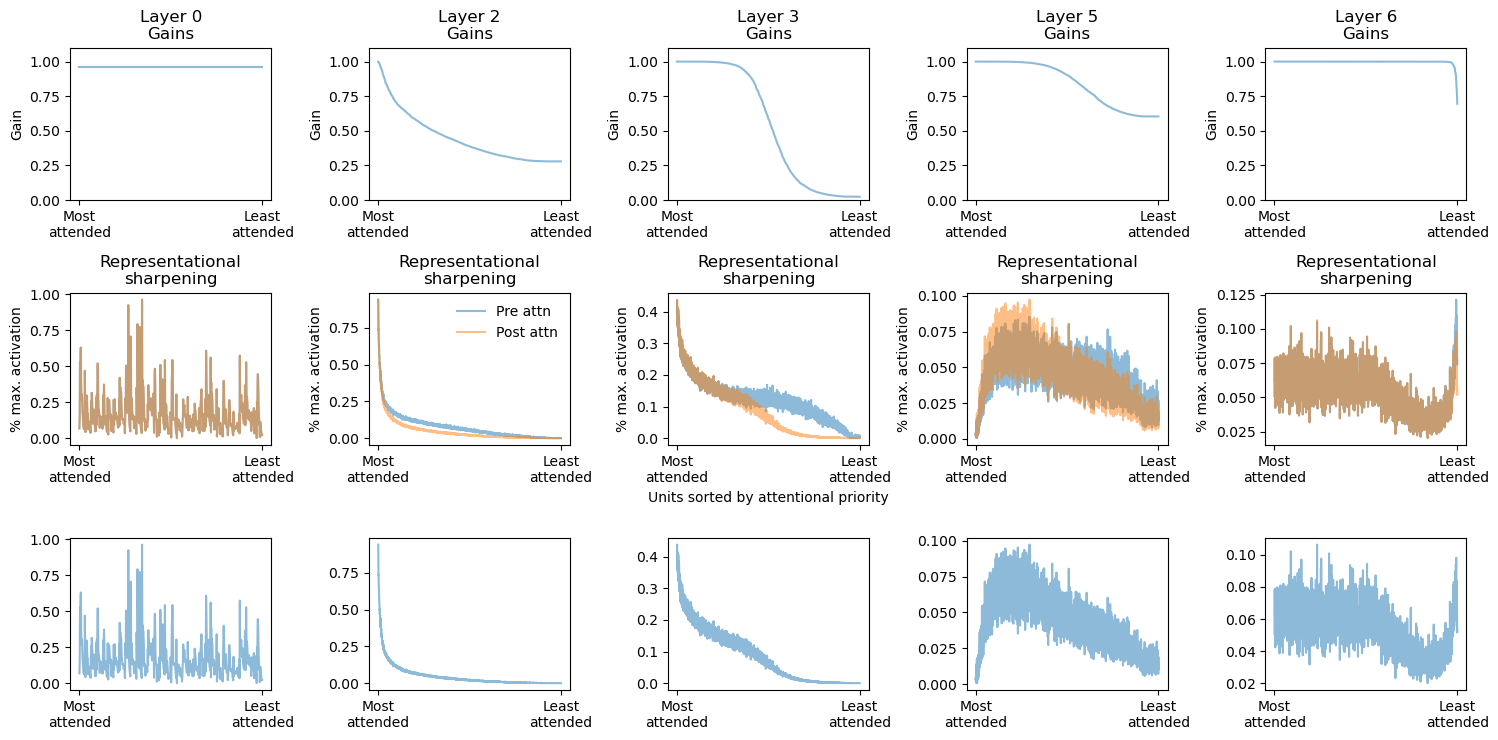

In [12]:
### Use same sex case as eg 

layer_ix = 2 # is 4th layer with 0 ix 
# sex_cond = 'diff'

n_examples = 100
layers_to_plot = [0, 2, 3, 5, 6]

fig, axs = plt.subplots(3,len(layers_to_plot), figsize=(15,7.5))

for plot_ix, layer_ix in enumerate(layers_to_plot):

    n_units = h5[f"hann_pool_{layer_ix}_target"].shape[1]
    # gain ix is layer_ix + 1
    if layer_ix == 6:
        gain_key = "attnfc"
    else:
        gain_key = f"attn{layer_ix+1}"

    pre_gain_acts = np.zeros((n_examples, n_units))
    post_gain_acts = np.zeros((n_examples, n_units))

    rank_diffs = np.zeros((n_examples))
    for stim_ix in range(n_examples):
        target_alone = h5[f"hann_pool_{layer_ix}_target"][stim_ix]
        # distractor_alone = h5[f"hann_pool_{layer_ix}_{sex_cond}_sex_dist"][stim_ix]

        # get unit rank from gains 
        gains = h5[f'{gain_key}_gains'][stim_ix]
        unit_rank = np.argsort(gains)[::-1]
        target_unit_rank = np.argsort(target_alone)[::-1]

        rank_diffs[stim_ix] = np.sum(target_unit_rank - unit_rank)

        mixture_pre_attn = h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][stim_ix]
        mixture_post_attn = h5[f"{gain_key}_mixture_{sex_cond}"][stim_ix]

        pre_gain_acts[stim_ix] = minmax_norm(mixture_pre_attn[unit_rank])
        post_gain_acts[stim_ix] = minmax_norm(mixture_post_attn[unit_rank])

    
    axs[0,plot_ix].plot(gains[unit_rank],  alpha=0.5);
    axs[0, plot_ix].set_ylim(0,1.1)

    axs[1,plot_ix].plot(pre_gain_acts.mean(0), label='Pre attn', alpha=0.5);
    axs[1, plot_ix].plot(post_gain_acts.mean(0), label='Post attn', alpha=0.5);
    # Plot difference 
    
    axs[2, plot_ix].plot(post_gain_acts.mean(0), label='Post attn', alpha=0.5);

    for ax in axs[:, plot_ix]:
        ax.set_xticks([0, n_units])
        ax.set_xticklabels(['Most\nattended', 'Least\nattended'])
        # ax.set_ylabel("Relative reduction\nin activation");
    if plot_ix == 2:
        axs[1, plot_ix].set_xlabel("Units sorted by attentional priority")

    if plot_ix == 1:
        # add legend 
        axs[1,plot_ix].legend(frameon=False)

    axs[0, plot_ix].set_title(f"Layer {layer_ix}\nGains")
    axs[1, plot_ix].set_title(f"Representational\nsharpening")
    axs[1, plot_ix].set_ylabel("% max. activation")
    axs[0, plot_ix].set_ylabel("Gain")
# plt.subplot(122)

plt.tight_layout()

In [1]:
import scipy
scipy.__version__

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


'1.6.2'

In [ ]:
import scipy.stats as stats


TypeError: fit() missing 1 required positional argument: 'data'

2560


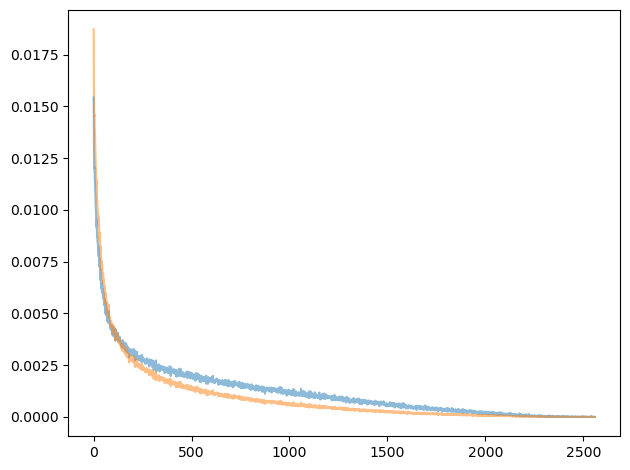

In [104]:
### Use same sex case as eg 

layer_ix = 2 # is 4th layer with 0 ix 
sex_cond = 'same'
n_units = h5[f"hann_pool_{layer_ix}_target"].shape[1]
print(n_units)
n_examples = 100
pre_gain_acts = np.zeros((n_examples, n_units))
post_gain_acts = np.zeros((n_examples, n_units))
for stim_ix in range(n_examples):
    target_alone = h5[f"hann_pool_{layer_ix}_target"][stim_ix]
    # distractor_alone = h5[f"hann_pool_{layer_ix}_{sex_cond}_sex_dist"][stim_ix]

    # get unit rank from gains 
    gains = h5[f'attn{layer_ix+1}_gains'][stim_ix]
    unit_rank = np.argsort(gains)[::-1]
    target_unit_rank = np.argsort(target_alone)[::-1]

    

    mixture_pre_attn = h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][stim_ix]
    mixture_post_attn = h5[f"attn{layer_ix+1}_mixture_{sex_cond}"][stim_ix]


    # unit_rank, unit_act_ratios = get_unit_affinity_rank(target_alone, distractor_alone)
    pre_gain_acts[stim_ix] = mixture_pre_attn[unit_rank]
    post_gain_acts[stim_ix] = mixture_post_attn[unit_rank]

# plt.hist(mixture_pre_attn, bins=20, alpha=0.5, label='Pre attn')
# plt.hist(mixture_post_attn, bins=20, alpha=0.5, label='Post attn')

## norm representations  
# plt.subplot(121)
plt.plot(unit_norm(pre_gain_acts, 2).mean(0), label='Pre attn', alpha=0.5);
plt.plot(unit_norm(post_gain_acts,2).mean(0), label='post attn', alpha=0.5);
# plt.subplot(122)

plt.tight_layout()

In [105]:
dist = stats.rv_discrete()

In [106]:
dist

In [107]:
distributions = [stats.norm, stats.expon, stats.gamma, stats.lognorm]

best_dist = None
best_ks_stat = np.inf

activations_flat = unit_norm(pre_gain_acts, 2).mean(0)

for dist in distributions:
    params = dist.fit(activations_flat)
    ks_stat, p_value = stats.kstest(activations_flat, dist.cdf, args=params)
    
    if ks_stat < best_ks_stat:
        best_ks_stat = ks_stat
        best_dist = (dist, params)

print(f"Best fitting distribution: {best_dist[0].name} with parameters {best_dist[1]}")

Best fitting distribution: gamma with parameters (0.7006308049822089, 5.5997237829526756e-08, 0.0017793781892384585)


In [108]:
pre_gain_acts

array([[6.48188019e+00, 5.67549658e+00, 5.19478273e+00, ...,
        1.05837756e-03, 3.09706060e-03, 0.00000000e+00],
       [3.94264150e+00, 4.53463459e+00, 3.86856198e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.56011868e+00, 5.50372458e+00, 4.65556431e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [5.63675785e+00, 5.36687469e+00, 4.95616817e+00, ...,
        1.21804010e-02, 2.18385435e-03, 0.00000000e+00],
       [5.33951235e+00, 4.11672926e+00, 4.75333977e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.55923653e+00, 6.08732653e+00, 4.13936710e+00, ...,
        2.90008518e-03, 3.70635744e-03, 0.00000000e+00]])

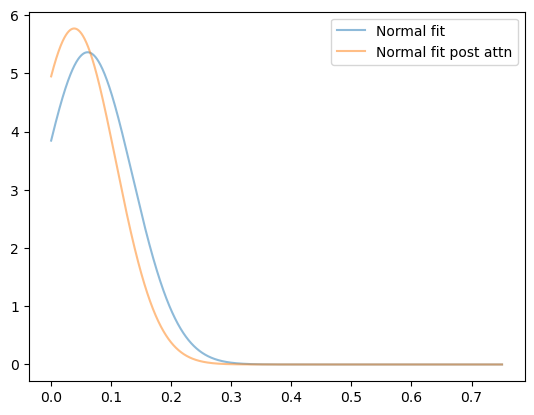

In [121]:
activations = minmax_norm(pre_gain_acts).mean(0)
post_activations = minmax_norm(post_gain_acts).mean(0)
# Fit a gamma distribution
shape, loc, scale = stats.gamma.fit(activations)

# Generate the fitted gamma PDF
# x = np.linspace(min(activations), max(activations), 100)
# pdf_fitted = stats.gamma.pdf(x, shape, loc=loc, scale=scale)

# fit normal distribution to each set of activations 

# Fit a normal distribution
mu, std = stats.norm.fit(activations)
mu_post, std_post = stats.norm.fit(post_activations)

# Generate the fitted normal PDF
x = np.linspace(min(activations), max(activations), len(activations))
pdf_fitted = stats.norm.pdf(x, mu, std)
pdf_fitted_post = stats.norm.pdf(x, mu_post, std_post)

# Plot the histogram and the fitted normal PDF
# plt.plot(activations, alpha=0.5, label='Pre attn')
# plt.plot(post_activations,  alpha=0.5, label='Post attn')
plt.plot(x, pdf_fitted, label='Normal fit', alpha=0.5)
plt.plot(x, pdf_fitted_post, label='Normal fit post attn', alpha=0.5)
plt.legend()


In [143]:
post_test = scipy.stats.skewtest(post_activations).statistic

In [144]:
pre_test = scipy.stats.skewtest(activations).statistic

In [145]:
pre_test

35.67260503591459

### Old stuff

### Dev target act measures

9 10


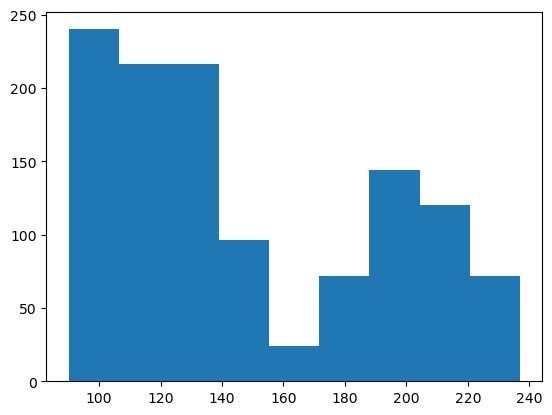

In [21]:
outs = plt.hist(target_f0s, bins=9)
counts, bins = outs[0], outs[1]
print(len(counts), len(bins))
f0_assignments = np.digitize(target_f0s, bins, right=True)
bins = bins.round(0)
f0_bins = bins[f0_assignments]
f0_bins = f0_bins.astype(int)

# group like with locations 
f0_ixs = {}
for f0 in np.unique(f0_bins):
    f0_ixs[f"{f0} Hz"] = np.where(f0_bins == f0)[0]

In [22]:
unique_locs = np.unique(target_locs, axis=0)
unique_f0s = np.unique(f0_bins)

unique_features = list(unique_locs) + list(unique_f0s)
# isinstance(unique_features[-1], int)
unique_features

[array([  0., -20.], dtype=float32),
 array([0., 0.], dtype=float32),
 array([ 0., 10.], dtype=float32),
 array([ 0., 20.], dtype=float32),
 array([ 0., 40.], dtype=float32),
 array([10.,  0.], dtype=float32),
 array([45.,  0.], dtype=float32),
 array([90.,  0.], dtype=float32),
 array([180.,   0.], dtype=float32),
 array([270.,   0.], dtype=float32),
 array([315.,   0.], dtype=float32),
 array([350.,   0.], dtype=float32),
 90,
 106,
 123,
 139,
 155,
 172,
 188,
 204,
 221,
 237]

In [12]:
# get act selectivity ratio 

def unit_act_ratio(target, distractor):
    """Get log ratio of target and distractor activations per unit"""
    ratios = np.log(target) - np.log(distractor)
    # set nans and infs to 0 - dead units stay 0 this way 
    ratios = np.nan_to_num(ratios, nan=0, posinf=0, neginf=0)
    return ratios

def get_act_delta(target_features, gains):
    q_feats = gains * target_features
    act_delta = (q_feats - target_features ) / np.abs(target_features)
    return act_delta

def get_unit_act_deltas(target_features, distractor_features, gains):
    unit_act_ratios = unit_act_ratio(target_features, distractor_features)
    unit_rank = np.argsort(unit_act_ratios)[::-1]
    unit_act_deltas = get_act_delta(target_features, gains)
    return unit_act_deltas[unit_rank]


# unit_act_ratios = unit_act_ratio(target_features, distractor_features)
# # rank units by selectivity
# unit_rank = np.argsort(unit_act_ratios)[::-1]

# get diverging color map so elements with unit_act_ratio > 0 are one color, and < 0 are another 
# avg_feature_gains = gain_avg_dict[str(target_locs[target_ix])]

# eg target azim:

examp_ixs = np.arange(target_locs.shape[0])
# colors = sns.color_palette("PiYG", n_colors=n_units)
# colors = np.array(colors)

layer_results_dict = {}
for layer_ix in range(7):
    print(layer_ix)
    n_units = h5[f"hann_pool_{layer_ix}_cue"].shape[1]
    # gain ix is layer_ix + 1
    if layer_ix == 6:
        gains = h5[f"attnfc_gains"][:]
    else:
        gains = h5[f"attn{layer_ix+1}_gains"][:]
    gain_avg_dict = {}
    for unique_feat in unique_features:
        if isinstance(unique_feat, np.int64):
            gain_ixs = (f0_bins == unique_feat)
        else:
            gain_ixs = (target_locs == unique_feat).all(axis=1)
        avg_gains = gains[gain_ixs].mean(0)
        gain_avg_dict[str(unique_feat)] = {'gains':avg_gains, 'feature':unique_feat}

    feat_delta_dict = {}
    for feat_key, feat_vals in gain_avg_dict.items():
        avg_feature_gains = feat_vals['gains']
        feature = feat_vals['feature']
        if isinstance(feature, np.int64):
            target_ixs = np.where(f0_bins == feature)[0]
        else:
            target_ixs = np.where((target_locs == feature).all(axis=1))[0]
        unit_act_deltas = np.zeros((len(target_ixs), n_units))

        valid_distractor_ixs = np.delete(examp_ixs, target_ixs)

        for ix, target_ix in enumerate(target_ixs):
            target_features = h5[f"s{layer_ix}_cue"][target_ix,:]
            distractor_ix = np.random.choice(valid_distractor_ixs).astype('int')
            distractor_features = h5[f"hann_pool_{layer_ix}_cue"][distractor_ix,:]
            unit_act_deltas[ix] = get_unit_act_deltas(target_features, distractor_features, avg_feature_gains)

        unit_act_deltas_avg = unit_act_deltas.mean(0)
        feat_delta_dict[feat_key] = unit_act_deltas_avg
    layer_results_dict[f"Layer {layer_ix}"] = feat_delta_dict
    # print(feat_delta_dict)

# plt.figure()

# plt.bar(np.arange(n_units), unit_act_deltas, alpha=0.5, color=colors)


0


/tmp/ipykernel_1789950/2987869986.py:5: RuntimeWarning: divide by zero encountered in log
  ratios = np.log(target) - np.log(distractor)
/tmp/ipykernel_1789950/2987869986.py:12: RuntimeWarning: invalid value encountered in divide
  act_delta = (q_feats - target_features ) / np.abs(target_features)


1


/tmp/ipykernel_1789950/2987869986.py:5: RuntimeWarning: invalid value encountered in subtract
  ratios = np.log(target) - np.log(distractor)


2
3
4
5
6


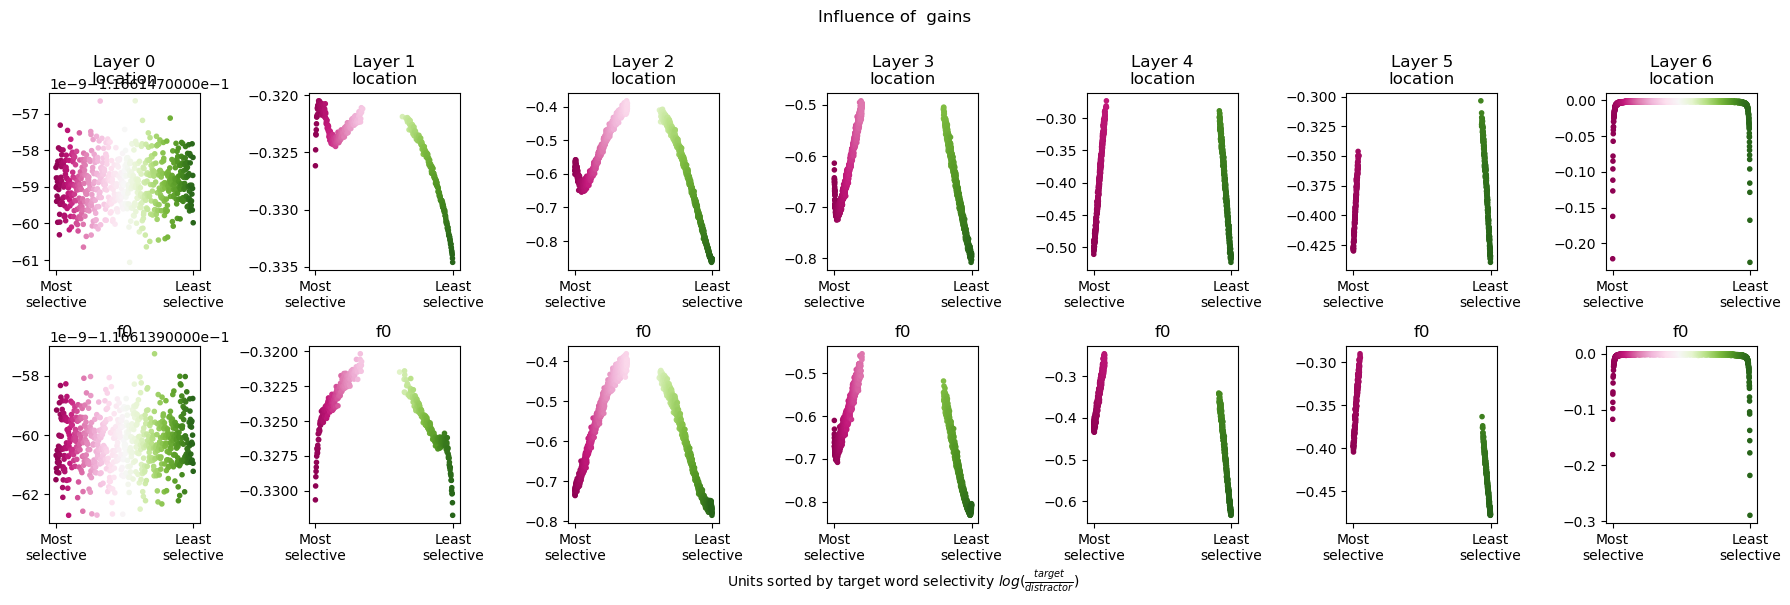

In [13]:
### Plot results for each layer 

## plot average deltas across keys 
fig, axs = plt.subplots(2,7, figsize=(18,6))

for ix, (layer, results) in enumerate(layer_results_dict.items()):
    global_avg_loc_deltas = np.array([vals for k, vals in results.items() if k.startswith('[')]).mean(0)
    global_avg_f0_deltas = np.array([vals for k, vals in results.items() if not k.startswith('[')]).mean(0)

    n_units = global_avg_loc_deltas.shape[0]
    colors = sns.color_palette("PiYG", n_colors=n_units)
    colors = np.array(colors)
    axs[0, ix].scatter(np.arange(n_units), global_avg_loc_deltas, color=colors,  marker='.')
    axs[1, ix].scatter(np.arange(n_units), global_avg_f0_deltas,  color=colors,  marker='.')
    axs[0,ix].set_title(f"{layer}\nlocation")
    axs[1,ix].set_title(f"f0")

    for ax in axs[:,ix]:
        ax.set_xticks([0, n_units])
        ax.set_xticklabels(['Most\nselective', 'Least\nselective'])
        # ax.set_ylim(0,1.01)
        # ax.set_ylabel("Relative reduction\nin activation");
    if ix == 3:
        axs[1,ix].set_xlabel("Units sorted by target word selectivity $log(\\frac{target}{distractor})$")
    # if ix == 0:
        # set as text between two rows 
# axs[0,0].set_ylabel( "Relative reduction in activation $(\\frac{attended - unattended}{unattended})$", rotation=90, va='center', ha='center', labelpad=20, y = -0.5)
# axs[0,0].set_ylabel( "Modulation in activation $(\\frac{attended}{unattended})$", rotation=90, va='center', ha='center', labelpad=20, y = -0.5)
plt.suptitle("Influence of  gains", y=1)
# fig.text( 1, 0, "Relative reduction in activation $(\\frac{attended - unattended}{unattended})$", rotation=90, va='center', ha='center')


plt.tight_layout()
# 

In [ ]:
## plot output of deltas for each key 

fig, axs = plt.subplots(3, len(feat_delta_dict)//3, figsize=(20, 5))
axs = axs.flatten()
x = np.arange(n_units)
for i, (key, vals) in enumerate(feat_delta_dict.items()):
    axs[i].bar(x, vals, alpha=0.5, color=colors)
    axs[i].set_title(key)
plt.tight_layout()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x14c8cd406670> (for post_execute):


KeyboardInterrupt: 

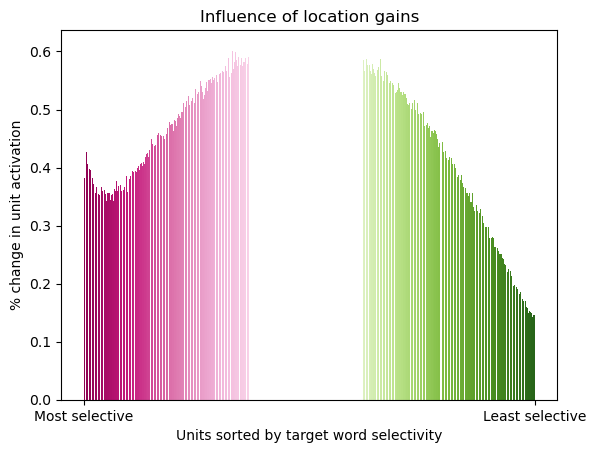

In [79]:
## plot average deltas across keys 

global_avg_deltas = np.array([vals for vals in feat_delta_dict.values()]).mean(0)
plt.figure()
x = np.arange(n_units)
plt.bar(x, global_avg_deltas,  color=colors)
plt.title("Influence of location gains")
# set xticks at 0 and max 
plt.xticks([0, n_units], ['Most selective', 'Least selective'])
plt.xlabel("Units sorted by target word selectivity")
plt.ylabel("% change in unit activation");


## Run for all layers

In [ ]:
## Implement above, but for all layers in the network (ixs 0 - 6 )
